# Importing the Necessary Libraries

In [86]:
import pandas as pd
from sklearn.utils import resample
import numpy as np
import pandas as pd 
from sklearn.model_selection import train_test_split   
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import MinMaxScaler
from sklearn import preprocessing
from sklearn.tree import DecisionTreeClassifier
import scikitplot as skplt 

In [2]:
df_1 = pd.read_csv("/Users/akshitkamboj/Desktop/Heart Dataset/data.csv")

In [3]:
df_1

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [4]:
df_2 = pd.read_csv("/Users/akshitkamboj/Desktop/Heart Dataset/reprocessed.hungarian (1).data")

In [6]:
df_2.head()

,40 1 2 140 289 0 0 172 0 0 -9 -9 -9 0
0,49 0 3 160 180 0 0 156 0 1 2 -9 -9 1
1,37 1 2 130 283 0 1 98 0 0 -9 -9 -9 0
2,48 0 4 138 214 0 0 108 1 1.5 2 -9 -9 3
3,54 1 3 150 -9 0 0 122 0 0 -9 -9 -9 0
4,39 1 3 120 339 0 0 170 0 0 -9 -9 -9 0


In [7]:
df_2.shape

(293, 1)

In [8]:
df_2.columns

Index(['40 1 2 140 289 0 0 172 0 0 -9 -9 -9 0'], dtype='object')

In [9]:
column_names = ["age", "sex", "cp", "trestbps", "chol", "fbs", "restecg", "thalach", "exang", "oldpeak", "slope", "ca", "thal",
               "target"]

column_names

['age',
 'sex',
 'cp',
 'trestbps',
 'chol',
 'fbs',
 'restecg',
 'thalach',
 'exang',
 'oldpeak',
 'slope',
 'ca',
 'thal',
 'target']

In [11]:
df_2 = pd.read_csv("/Users/akshitkamboj/Desktop/Heart Dataset/reprocessed.hungarian (1).data", names=column_names, delim_whitespace=True)

In [12]:
df_2

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,40,1,2,140,289,0,0,172,0,0.0,-9,-9,-9,0
1,49,0,3,160,180,0,0,156,0,1.0,2,-9,-9,1
2,37,1,2,130,283,0,1,98,0,0.0,-9,-9,-9,0
3,48,0,4,138,214,0,0,108,1,1.5,2,-9,-9,3
4,54,1,3,150,-9,0,0,122,0,0.0,-9,-9,-9,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
289,48,0,2,-9,308,0,1,-9,-9,2.0,1,-9,-9,0
290,36,1,2,120,166,0,0,180,0,0.0,-9,-9,-9,0
291,48,1,3,110,211,0,0,138,0,0.0,-9,-9,6,0
292,47,0,2,140,257,0,0,135,0,1.0,1,-9,-9,0


In [13]:
data = [df_1, df_2]
df_combined = pd.concat(data)

In [14]:
df_combined

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
289,48,0,2,-9,308,0,1,-9,-9,2.0,1,-9,-9,0
290,36,1,2,120,166,0,0,180,0,0.0,-9,-9,-9,0
291,48,1,3,110,211,0,0,138,0,0.0,-9,-9,6,0
292,47,0,2,140,257,0,0,135,0,1.0,1,-9,-9,0


In [15]:
df_3 = pd.read_csv("/Users/akshitkamboj/Desktop/Heart Dataset/processed.cleveland (1).data", names = column_names )

In [16]:
df_3

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45.0,1.0,1.0,110.0,264.0,0.0,0.0,132.0,0.0,1.2,2.0,0.0,7.0,1
299,68.0,1.0,4.0,144.0,193.0,1.0,0.0,141.0,0.0,3.4,2.0,2.0,7.0,2
300,57.0,1.0,4.0,130.0,131.0,0.0,0.0,115.0,1.0,1.2,2.0,1.0,7.0,3
301,57.0,0.0,2.0,130.0,236.0,0.0,2.0,174.0,0.0,0.0,2.0,1.0,3.0,1


In [17]:
df_3["ca"].value_counts()

0.0    176
1.0     65
2.0     38
3.0     20
?        4
Name: ca, dtype: int64

In [18]:
data = [df_combined, df_3]

In [19]:
df_combined = pd.concat(data)

In [20]:
df_combined

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52.0,1.0,0.0,125.0,212.0,0.0,1.0,168.0,0.0,1.0,2.0,2,3,0
1,53.0,1.0,0.0,140.0,203.0,1.0,0.0,155.0,1.0,3.1,0.0,0,3,0
2,70.0,1.0,0.0,145.0,174.0,0.0,1.0,125.0,1.0,2.6,0.0,0,3,0
3,61.0,1.0,0.0,148.0,203.0,0.0,1.0,161.0,0.0,0.0,2.0,1,3,0
4,62.0,0.0,0.0,138.0,294.0,1.0,1.0,106.0,0.0,1.9,1.0,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45.0,1.0,1.0,110.0,264.0,0.0,0.0,132.0,0.0,1.2,2.0,0.0,7.0,1
299,68.0,1.0,4.0,144.0,193.0,1.0,0.0,141.0,0.0,3.4,2.0,2.0,7.0,2
300,57.0,1.0,4.0,130.0,131.0,0.0,0.0,115.0,1.0,1.2,2.0,1.0,7.0,3
301,57.0,0.0,2.0,130.0,236.0,0.0,2.0,174.0,0.0,0.0,2.0,1.0,3.0,1


In [119]:
df_copy = df_combined.copy()
df_copy_2 = df_combined.copy()

In [22]:
df_copy.drop_duplicates(inplace=True)

In [23]:
df_copy 

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52.0,1.0,0.0,125.0,212.0,0.0,1.0,168.0,0.0,1.0,2.0,2,3,0
1,53.0,1.0,0.0,140.0,203.0,1.0,0.0,155.0,1.0,3.1,0.0,0,3,0
2,70.0,1.0,0.0,145.0,174.0,0.0,1.0,125.0,1.0,2.6,0.0,0,3,0
3,61.0,1.0,0.0,148.0,203.0,0.0,1.0,161.0,0.0,0.0,2.0,1,3,0
4,62.0,0.0,0.0,138.0,294.0,1.0,1.0,106.0,0.0,1.9,1.0,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45.0,1.0,1.0,110.0,264.0,0.0,0.0,132.0,0.0,1.2,2.0,0.0,7.0,1
299,68.0,1.0,4.0,144.0,193.0,1.0,0.0,141.0,0.0,3.4,2.0,2.0,7.0,2
300,57.0,1.0,4.0,130.0,131.0,0.0,0.0,115.0,1.0,1.2,2.0,1.0,7.0,3
301,57.0,0.0,2.0,130.0,236.0,0.0,2.0,174.0,0.0,0.0,2.0,1.0,3.0,1


In [23]:
df_copy  = df_copy.drop_duplicates(keep='first')

In [24]:
df_copy

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52.0,1.0,0.0,125.0,212.0,0.0,1.0,168.0,0.0,1.0,2.0,2,3,0
1,53.0,1.0,0.0,140.0,203.0,1.0,0.0,155.0,1.0,3.1,0.0,0,3,0
2,70.0,1.0,0.0,145.0,174.0,0.0,1.0,125.0,1.0,2.6,0.0,0,3,0
3,61.0,1.0,0.0,148.0,203.0,0.0,1.0,161.0,0.0,0.0,2.0,1,3,0
4,62.0,0.0,0.0,138.0,294.0,1.0,1.0,106.0,0.0,1.9,1.0,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45.0,1.0,1.0,110.0,264.0,0.0,0.0,132.0,0.0,1.2,2.0,0.0,7.0,1
299,68.0,1.0,4.0,144.0,193.0,1.0,0.0,141.0,0.0,3.4,2.0,2.0,7.0,2
300,57.0,1.0,4.0,130.0,131.0,0.0,0.0,115.0,1.0,1.2,2.0,1.0,7.0,3
301,57.0,0.0,2.0,130.0,236.0,0.0,2.0,174.0,0.0,0.0,2.0,1.0,3.0,1


In [25]:
df_copy = df_copy.drop_duplicates(subset=["age", "sex", "cp", "trestbps", "chol", "fbs", "restecg", "thalach", "exang", "oldpeak", "slope", "ca", "thal",
               "target"], keep= "first"   )

In [26]:
df_copy

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52.0,1.0,0.0,125.0,212.0,0.0,1.0,168.0,0.0,1.0,2.0,2,3,0
1,53.0,1.0,0.0,140.0,203.0,1.0,0.0,155.0,1.0,3.1,0.0,0,3,0
2,70.0,1.0,0.0,145.0,174.0,0.0,1.0,125.0,1.0,2.6,0.0,0,3,0
3,61.0,1.0,0.0,148.0,203.0,0.0,1.0,161.0,0.0,0.0,2.0,1,3,0
4,62.0,0.0,0.0,138.0,294.0,1.0,1.0,106.0,0.0,1.9,1.0,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45.0,1.0,1.0,110.0,264.0,0.0,0.0,132.0,0.0,1.2,2.0,0.0,7.0,1
299,68.0,1.0,4.0,144.0,193.0,1.0,0.0,141.0,0.0,3.4,2.0,2.0,7.0,2
300,57.0,1.0,4.0,130.0,131.0,0.0,0.0,115.0,1.0,1.2,2.0,1.0,7.0,3
301,57.0,0.0,2.0,130.0,236.0,0.0,2.0,174.0,0.0,0.0,2.0,1.0,3.0,1


In [24]:
df_combined["target"].value_counts()

0    851
1    618
3     63
2     62
4     28
Name: target, dtype: int64

In [25]:
df_1 = df_combined[df_combined["target"] == 1]
df_3 = df_combined[df_combined["target"] == 3]
df_4 = df_combined[df_combined["target"] == 4]
df_2 = df_combined[df_combined["target"] == 2]
df_0 = df_combined[df_combined["target"] == 0]

# Upsampling

In [27]:
df_3_upsampled = resample(df_3,
             replace=True,
             n_samples=len(df_1),
             random_state=42)

In [28]:
df_3_upsampled.shape

(618, 14)

In [29]:
df_4_upsampled = resample(df_4,
             replace=True,
             n_samples=len(df_1),
             random_state=42)

In [30]:
df_4_upsampled.shape

(618, 14)

In [31]:
df_2_upsampled = resample(df_2,
             replace=True,
             n_samples=len(df_1),
             random_state=42)

In [32]:
df_2_upsampled.shape

(618, 14)

In [33]:
data_upsampled = pd.concat([df_0, df_1, df_2_upsampled, df_3_upsampled, df_4_upsampled])

In [34]:
data_upsampled

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52.0,1.0,0.0,125.0,212.0,0.0,1.0,168.0,0.0,1.0,2.0,2,3,0
1,53.0,1.0,0.0,140.0,203.0,1.0,0.0,155.0,1.0,3.1,0.0,0,3,0
2,70.0,1.0,0.0,145.0,174.0,0.0,1.0,125.0,1.0,2.6,0.0,0,3,0
3,61.0,1.0,0.0,148.0,203.0,0.0,1.0,161.0,0.0,0.0,2.0,1,3,0
4,62.0,0.0,0.0,138.0,294.0,1.0,1.0,106.0,0.0,1.9,1.0,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45,58.0,1.0,3.0,112.0,230.0,0.0,2.0,165.0,0.0,2.5,2.0,1.0,7.0,4
100,65.0,1.0,4.0,130.0,275.0,0.0,1.0,115.0,1.0,1.0,2.0,-9,-9,4
285,58.0,1.0,4.0,114.0,318.0,0.0,1.0,140.0,0.0,4.4,3.0,3.0,6.0,4
41,54.0,0.0,3.0,130.0,294.0,0.0,1.0,100.0,1.0,0.0,2.0,-9,-9,4


In [35]:
data_upsampled["target"].value_counts()

0    851
1    618
2    618
3    618
4    618
Name: target, dtype: int64

In [36]:
data_upsampled.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3323 entries, 0 to 41
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       3323 non-null   float64
 1   sex       3323 non-null   float64
 2   cp        3323 non-null   float64
 3   trestbps  3323 non-null   float64
 4   chol      3323 non-null   float64
 5   fbs       3323 non-null   float64
 6   restecg   3323 non-null   float64
 7   thalach   3323 non-null   float64
 8   exang     3323 non-null   float64
 9   oldpeak   3323 non-null   float64
 10  slope     3323 non-null   float64
 11  ca        3323 non-null   object 
 12  thal      3323 non-null   object 
 13  target    3323 non-null   int64  
dtypes: float64(11), int64(1), object(2)
memory usage: 389.4+ KB


In [37]:
data_upsampled.drop(data_upsampled[data_upsampled['ca'] == "?"].index, inplace = True)

In [38]:
data_upsampled.drop(data_upsampled[data_upsampled['age'] == "?"].index, inplace = True)
data_upsampled.drop(data_upsampled[data_upsampled['sex'] == "?"].index, inplace = True)
data_upsampled.drop(data_upsampled[data_upsampled['cp'] == "?"].index, inplace = True)
data_upsampled.drop(data_upsampled[data_upsampled['trestbps'] == "?"].index, inplace = True)
data_upsampled.drop(data_upsampled[data_upsampled['chol'] == "?"].index, inplace = True)
data_upsampled.drop(data_upsampled[data_upsampled['fbs'] == "?"].index, inplace = True)
data_upsampled.drop(data_upsampled[data_upsampled['restecg'] == "?"].index, inplace = True)
data_upsampled.drop(data_upsampled[data_upsampled['thalach'] == "?"].index, inplace = True)
data_upsampled.drop(data_upsampled[data_upsampled['exang'] == "?"].index, inplace = True)
data_upsampled.drop(data_upsampled[data_upsampled['oldpeak'] == "?"].index, inplace = True)
data_upsampled.drop(data_upsampled[data_upsampled['slope'] == "?"].index, inplace = True)
data_upsampled.drop(data_upsampled[data_upsampled['thal'] == "?"].index, inplace = True)

In [132]:
data_upsampled['target'].value_counts()

0    840
4    618
1    614
3    611
2    607
Name: target, dtype: int64

In [133]:
df_copy_2 = data_upsampled.copy()

In [40]:
df_copy = data_upsampled.copy() 

In [43]:
X = df_copy.drop(columns='target', axis = 1)
Y = df_copy['target']

In [44]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2 ,stratify=Y, random_state = 2)

In [45]:
print(X.shape, X_train.shape, X_test.shape)

(3290, 13) (2632, 13) (658, 13)


# Logistic Regression Model

In [46]:
model = LogisticRegression()

In [47]:
model.fit(X_train , Y_train)

/Users/akshitkamboj/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

# Accuracy on training data 

In [49]:
X_train_prediction = model.predict(X_train)
training_data_accuracy = accuracy_score(X_train_prediction, Y_train)
print("Accuracy on Training data : " , training_data_accuracy)

Accuracy on Training data :  0.4992401215805471


# Accuracy on Testing data 

In [50]:
X_test_prediction = model.predict(X_test)
test_data_accuracy = accuracy_score(X_test_prediction, Y_test)
print('Accuracy on Test data :' , test_data_accuracy)

Accuracy on Test data : 0.5045592705167173


In [51]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2632 entries, 60 to 121
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2632 non-null   float64
 1   sex       2632 non-null   float64
 2   cp        2632 non-null   float64
 3   trestbps  2632 non-null   float64
 4   chol      2632 non-null   float64
 5   fbs       2632 non-null   float64
 6   restecg   2632 non-null   float64
 7   thalach   2632 non-null   float64
 8   exang     2632 non-null   float64
 9   oldpeak   2632 non-null   float64
 10  slope     2632 non-null   float64
 11  ca        2632 non-null   object 
 12  thal      2632 non-null   object 
dtypes: float64(11), object(2)
memory usage: 287.9+ KB


# Scaling the Dataset

In [55]:
scalar = MinMaxScaler().fit(X_train)

In [56]:
X_train_scaled  =  scalar.transform(X_train)
X_test_scaled = scalar.transform(X_test)

In [57]:
X_train_scaled  

array([[0.42857143, 1.        , 0.5       , ..., 0.        , 0.        ,
        0.        ],
       [0.6122449 , 1.        , 1.        , ..., 1.        , 0.66666667,
        0.9375    ],
       [0.30612245, 0.        , 0.        , ..., 0.83333333, 0.5       ,
        0.75      ],
       ...,
       [0.53061224, 0.        , 0.5       , ..., 0.91666667, 0.5       ,
        0.6875    ],
       [0.34693878, 1.        , 1.        , ..., 0.91666667, 0.66666667,
        1.        ],
       [0.71428571, 0.        , 1.        , ..., 0.91666667, 0.66666667,
        1.        ]])

# Support Vector Machine

## Taking Random Sample for SVM

In [134]:
random_sample = df_copy_2.sample(frac = 0.20)
# random_sample.drop(['Name', 'md5'], axis = 1, inplace = True)
svm_y = random_sample['target']
random_sample = random_sample.drop(['target'], axis = 1)

## Scaling the Random Sample

In [135]:
random_sample_scaled = scalar.transform(random_sample)

## Training the SVM Model

In [136]:
svm_model = svm.SVC()
svm_model.fit(random_sample, svm_y)

SVC()

In [137]:
train_preds_svm = svm_model.predict(X_train_scaled)
accuracy_score(Y_train, train_preds_svm)

/Users/akshitkamboj/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


0.185790273556231

In [138]:
test_preds_svm = svm_model.predict(X_test_scaled)
accuracy_score(Y_test, test_preds_svm)

/Users/akshitkamboj/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


0.18541033434650456

## Confusion Matrix

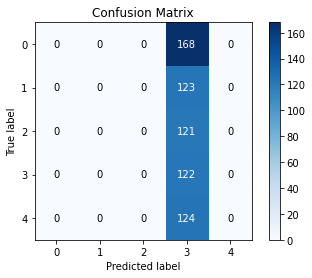

In [141]:
cm_bn_rf = skplt.metrics.plot_confusion_matrix(Y_test, test_preds_svm, normalize = None)

## Confusion Matrix - Normalized

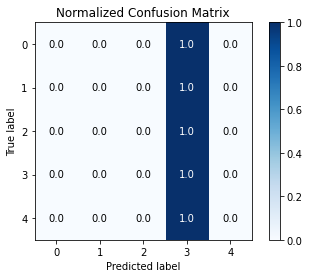

In [142]:
cm_bn_rf = skplt.metrics.plot_confusion_matrix(Y_test, test_preds_svm, normalize = True)

# Decision Tree Classifier

In [88]:
from sklearn.tree import DecisionTreeClassifier

In [89]:
dt_model_scaled = DecisionTreeClassifier(random_state = 2 , max_leaf_nodes = 2**20)
dt_model_scaled.fit(X_train_scaled, Y_train)

DecisionTreeClassifier(max_leaf_nodes=1048576, random_state=2)

In [90]:
train_preds = dt_model_scaled.predict(X_train_scaled)

In [91]:
accuracy_score(train_preds,Y_train)

1.0

In [92]:
test_preds = dt_model_scaled.predict(X_test_scaled)
accuracy_score(test_preds,Y_test)

0.939209726443769

## Confusion Matrix

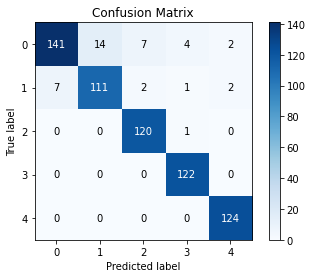

In [93]:
cm_bn_rf = skplt.metrics.plot_confusion_matrix(Y_test, test_preds, normalize = None)

## Confusion Matrix - Normalized

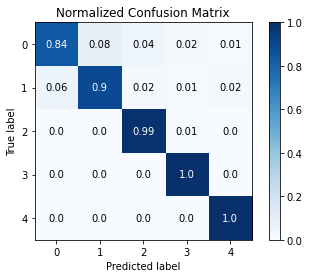

In [94]:
cm_bn_rf = skplt.metrics.plot_confusion_matrix(Y_test, test_preds, normalize = True)

# RANDOM FOREST CLASSFIER 

In [65]:
from sklearn.ensemble import RandomForestClassifier

In [66]:
random_model_scaled = RandomForestClassifier(random_state = 2, n_jobs = -1, max_leaf_nodes = 2**20)
random_model_scaled.fit(X_train_scaled,Y_train)

train_preds = random_model_scaled.predict(X_train_scaled)
accuracy_score(train_preds, Y_train)

1.0

In [67]:
test_preds = random_model_scaled.predict(X_test_scaled)
accuracy_score(test_preds, Y_test)

0.952887537993921

## Confusion Matrix

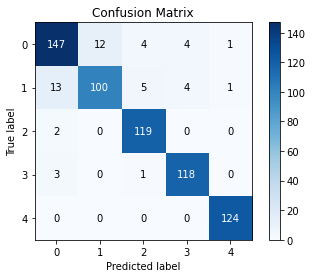

In [85]:
cm_bn_rf = skplt.metrics.plot_confusion_matrix(Y_test, test_preds, normalize = None)

## Confusion Matrix - Normalized

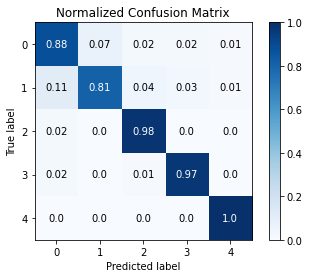

In [87]:
cm_bn_rf = skplt.metrics.plot_confusion_matrix(Y_test, test_preds, normalize = True)

In [68]:
from sklearn.metrics import f1_score, accuracy_score, plot_confusion_matrix, auc, confusion_matrix

# XGBoost Model

In [95]:
from xgboost import XGBClassifier

xg_model_scaled = XGBClassifier()
xg_model_scaled.fit(X_train_scaled, Y_train)

train_preds = xg_model_scaled.predict(X_train_scaled)
accuracy_score(Y_train, train_preds)

/Users/akshitkamboj/opt/anaconda3/lib/python3.9/site-packages/xgboost/sklearn.py:1224: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)


[12:42:50] WARNING: ../src/learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'multi:softprob' was changed from 'merror' to 'mlogloss'. Explicitly set eval_metric if you'd like to restore the old behavior.


1.0

In [96]:
test_preds = xg_model_scaled.predict(X_test_scaled)
accuracy_score(test_preds, Y_test)

0.9468085106382979

## Confusion Matrix

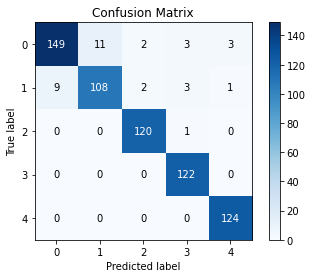

In [97]:
cm_bn_rf = skplt.metrics.plot_confusion_matrix(Y_test, test_preds, normalize = None)

## Confusion Matrix - Normalized

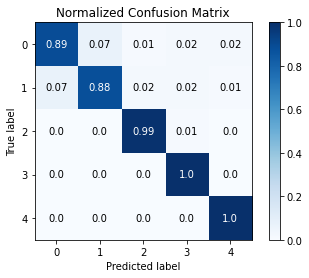

In [98]:
cm_bn_rf = skplt.metrics.plot_confusion_matrix(Y_test, test_preds, normalize = True)

# Gradient Boosting Model

In [99]:
from sklearn.ensemble import GradientBoostingClassifier

gbc_model_scaled = GradientBoostingClassifier()
gbc_model_scaled.fit(X_train_scaled, Y_train)

train_preds = gbc_model_scaled.predict(X_train_scaled)
accuracy_score(train_preds, Y_train)

0.9456686930091185

In [100]:
test_preds = gbc_model_scaled.predict(X_test_scaled)
accuracy_score(test_preds, Y_test)

0.9240121580547113

## Confusion Matrix

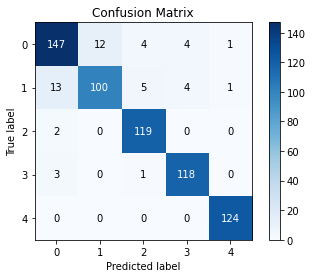

In [101]:
cm_bn_rf = skplt.metrics.plot_confusion_matrix(Y_test, test_preds, normalize = None)

## Confusion Matrix - Normalized

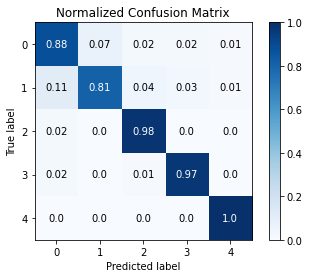

In [102]:
cm_bn_rf = skplt.metrics.plot_confusion_matrix(Y_test, test_preds, normalize = True)

# AdaBoost Classifier

In [103]:
from sklearn.ensemble import AdaBoostClassifier

In [104]:
ada_model_scaled = AdaBoostClassifier(n_estimators=100, random_state = 2)
ada_model_scaled.fit(X_train_scaled, Y_train)

train_preds = ada_model_scaled.predict(X_train_scaled)
accuracy_score(train_preds, Y_train)

0.48214285714285715

In [105]:
test_preds = ada_model_scaled.predict(X_test_scaled)
accuracy_score(test_preds, Y_test)

0.49848024316109424

## Confusion Matrix

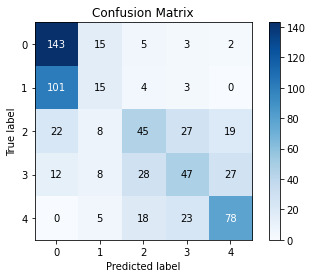

In [106]:
cm_bn_rf = skplt.metrics.plot_confusion_matrix(Y_test, test_preds, normalize = None)

## Confusion Matrix - Normalized

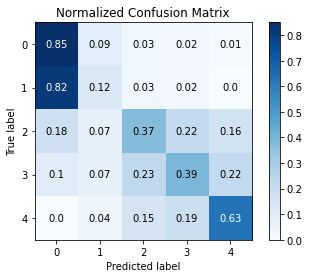

In [108]:
cm_bn_rf = skplt.metrics.plot_confusion_matrix(Y_test, test_preds, normalize = True)

# KMEANS CLUSTTERING 

In [109]:
from sklearn.cluster import KMeans

kmeans_model_scaled = KMeans(n_clusters = 2, random_state = 2)
kmeans_model_scaled.fit(X_train_scaled)

KMeans(n_clusters=2, random_state=2)

In [110]:
train_preds = kmeans_model_scaled.predict(X_train_scaled)
accuracy_score(Y_train, train_preds)

0.21466565349544073

In [111]:
test_preds = kmeans_model_scaled.predict(X_test_scaled)
accuracy_score(Y_test, test_preds)

0.20516717325227962

## Confusion Matrix

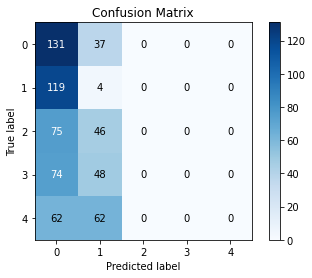

In [112]:
cm_bn_rf = skplt.metrics.plot_confusion_matrix(Y_test, test_preds, normalize = None)

## Confusion Matrix - Normalized

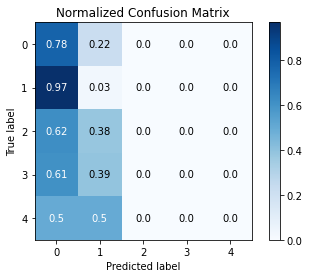

In [113]:
cm_bn_rf = skplt.metrics.plot_confusion_matrix(Y_test, test_preds, normalize = True)

# Gradient Boosting Model

In [114]:
from sklearn.ensemble import GradientBoostingClassifier

gbc_model_scaled = GradientBoostingClassifier()
gbc_model_scaled.fit(X_train_scaled, Y_train)

GradientBoostingClassifier()

In [115]:
train_preds = gbc_model_scaled.predict(X_train_scaled)
accuracy_score(train_preds, Y_train)

0.9456686930091185

In [116]:
test_preds = gbc_model_scaled.predict(X_test_scaled)
accuracy_score(test_preds, Y_test)

0.9240121580547113

## Confusion Matrix

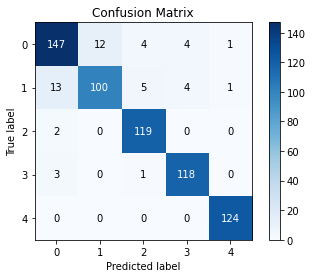

In [117]:
cm_bn_rf = skplt.metrics.plot_confusion_matrix(Y_test, test_preds, normalize = None)

## Confusion Matrix - Normalized

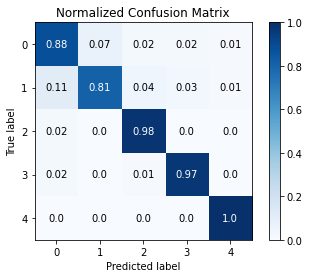

In [118]:
cm_bn_rf = skplt.metrics.plot_confusion_matrix(Y_test, test_preds, normalize = True)

# Plotting a Graph for Comparing Results

In [144]:
import matplotlib.pyplot as plt

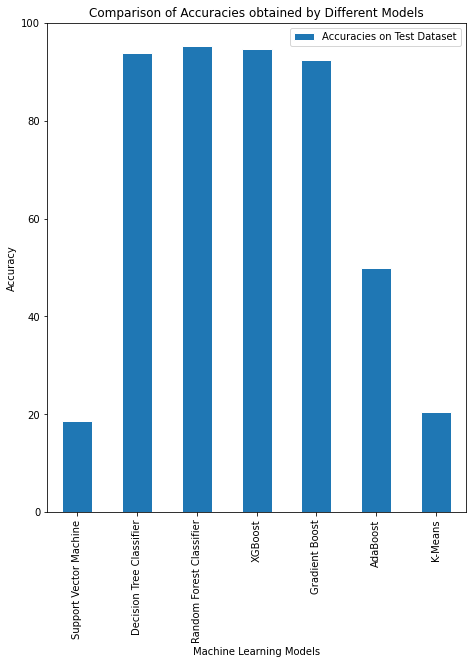

In [151]:
plt.rcParams["figure.figsize"] = [7.5, 9]

d = {'Accuracies on Test Dataset': [18.54, 93.92, 95.28, 94.68, 92.40, 49.84, 20.51]}

df = pd.DataFrame(d)
df.plot(kind = 'bar', edgecolor = 'white', linewidth = 1)
plt.xticks([0, 1, 2, 3, 4, 5, 6], ['Support Vector Machine', 'Decision Tree Classifier', 'Random Forest Classifier', 'XGBoost',
                             'Gradient Boost', 'AdaBoost', 'K-Means'])

plt.title('Comparison of Accuracies obtained by Different Models')
plt.xlabel('Machine Learning Models')
plt.ylabel('Accuracy')

plt.show()

# Support Vector Machine

In [82]:
from sklearn import svm

In [122]:
random_sample = X_train.sample(frac = 0.20)

In [ ]:
svm_model = svm.SVC()
svm_model.fit(random_sample, svm_y)

In [57]:
normalized

array([[ 0.14984359,  0.00305803,  0.00611606, ..., -0.02752229,
        -0.02752229, -0.02752229],
       [ 0.15659934,  0.00269999,  0.01079995, ...,  0.00809997,
         0.00809997,  0.01619993],
       [ 0.1095489 ,  0.        ,  0.        , ...,  0.00254765,
         0.        ,  0.00764295],
       ...,
       [ 0.14306405,  0.        ,  0.00529867, ...,  0.00529867,
         0.        ,  0.00529867],
       [ 0.1205421 ,  0.00267871,  0.01071485, ...,  0.00535743,
         0.00803614,  0.01875099],
       [ 0.13557576,  0.        ,  0.00860798, ...,  0.00430399,
         0.00645599,  0.01506397]])

In [58]:
model.fit(normalized , Y_train)

C:\Users\rajni\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [59]:
X_train_prediction = model.predict(normalized)
training_data_accuracy = accuracy_score(X_train_prediction, Y_train)
print("Accuracy on Training data : " , training_data_accuracy)

Accuracy on Training data :  0.32940729483282677


In [60]:
from sklearn.ensemble import RandomForestRegressor

regressor = RandomForestRegressor(n_estimators = 100, random_state = 2)
  
# fit the regressor with x and y data
regressor.fit(X_train, Y_train)

RandomForestRegressor(random_state=2)

In [66]:
from sklearn import metrics 

In [68]:
X_train_prediction = regressor.predict(X_train)
# training_data_accuracy = metrics.accuracy_score(X_train_prediction, Y_train)
# int("Accuracy on Training data : " , training_data_accuracy)

In [69]:
X_train_prediction

array([0.14, 4.  , 0.  , ..., 0.99, 3.  , 4.  ])

In [ ]:
X_test_prediction = model.